In [1]:
import pandas as pd
import numpy as np
import platform
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler

In [2]:
os = platform.system()

# 한글이 깨지지 않는 폰트로 수정
if os == 'Windows':
    plt.rc('font', family= 'Malgun Gothic')
    
elif os == 'Darwin':
    plt.rc('font', family= 'AppleGothic')

elif os == 'Linux':
    plt.rc('font', family= 'NanumGothic')

else:
    print(f'{os} is not set')

In [3]:
df = pd.read_csv("../data/ai4i2020.csv")

In [4]:
df = df.rename(columns={
    "UDI": "고유번호",
    "Product ID": "제품ID",
    "Type": "제품등급",
    "Air temperature [K]": "주변온도_K",
    "Process temperature [K]": "공정온도_K",
    "Rotational speed [rpm]": "회전속도_rpm",
    "Torque [Nm]": "토크_Nm",
    "Tool wear [min]": "공구마모_분",
    "Machine failure": "기계고장",
    "TWF": "공구마모고장",
    "HDF": "열방출고장",
    "PWF": "동력고장",
    "OSF": "과부하고장",
    "RNF": "무작위고장"
})

In [5]:
df.head()

,고유번호,제품ID,제품등급,주변온도_K,공정온도_K,회전속도_rpm,토크_Nm,공구마모_분,기계고장,공구마모고장,열방출고장,동력고장,과부하고장,무작위고장
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


In [6]:
df.describe()

,고유번호,주변온도_K,공정온도_K,회전속도_rpm,토크_Nm,공구마모_분,기계고장,공구마모고장,열방출고장,동력고장,과부하고장,무작위고장
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000
mean,5000.50000,300.004930,310.005560,1538.776100,39.986910,107.951000,0.033900,0.004600,0.011500,0.009500,0.009800,0.00190
std,2886.89568,2.000259,1.483734,179.284096,9.968934,63.654147,0.180981,0.067671,0.106625,0.097009,0.098514,0.04355
min,1.00000,295.300000,305.700000,1168.000000,3.800000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
25%,2500.75000,298.300000,308.800000,1423.000000,33.200000,53.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
50%,5000.50000,300.100000,310.100000,1503.000000,40.100000,108.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
75%,7500.25000,301.500000,311.100000,1612.000000,46.800000,162.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
max,10000.00000,304.500000,313.800000,2886.000000,76.600000,253.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000


In [7]:
len(df)

10000

In [8]:
df['기계고장'].value_counts(normalize=True)*100

기계고장
0    96.61
1     3.39
Name: proportion, dtype: float64

In [9]:
df['기계고장'].value_counts()

기계고장
0    9661
1     339
Name: count, dtype: int64

In [10]:
df['공구마모고장'].value_counts()

공구마모고장
0    9954
1      46
Name: count, dtype: int64

In [11]:
df['열방출고장'].value_counts()

열방출고장
0    9885
1     115
Name: count, dtype: int64

In [12]:
df['동력고장'].value_counts()

동력고장
0    9905
1      95
Name: count, dtype: int64

In [13]:
df['과부하고장'].value_counts()

과부하고장
0    9902
1      98
Name: count, dtype: int64

In [14]:
df['무작위고장'].value_counts()

무작위고장
0    9981
1      19
Name: count, dtype: int64

In [15]:
fails = ['공구마모고장','열방출고장','동력고장','과부하고장','무작위고장']

In [16]:
df_fail = df.drop(columns=(fails+['고유번호']))

In [17]:
df_fail = df_fail[[c for c in df_fail if c != '기계고장'] + ['기계고장']]

c:\Users\JUNSOO\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) Malgun Gothic.
  fig.canvas.draw()
C:\Users\JUNSOO\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) Malgun Gothic.
  fig.canvas.print_figure(bytes_io, **kw)


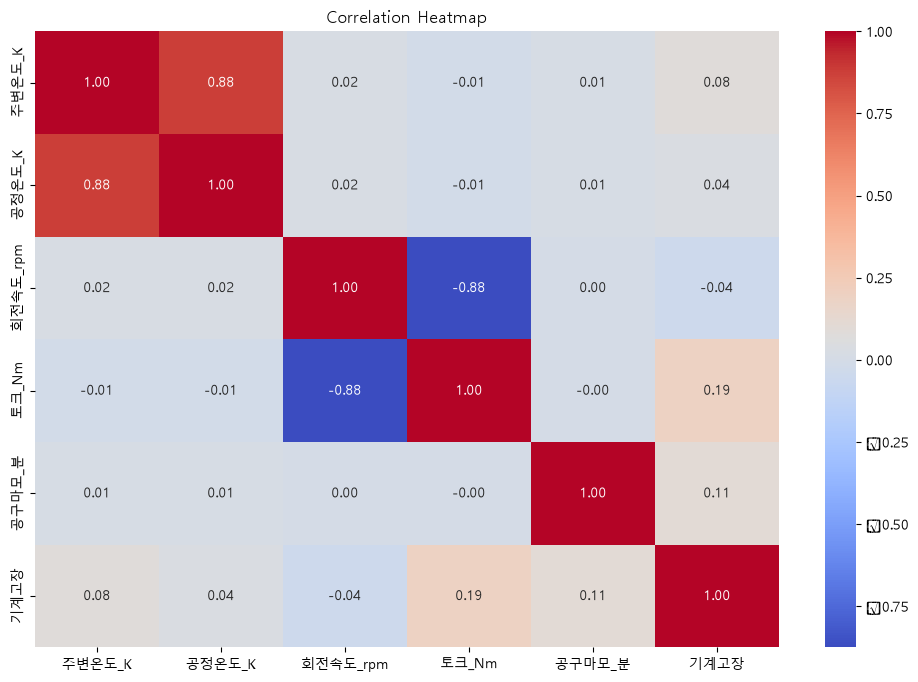

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 8))

corr = df_fail.corr(numeric_only=True)

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")
plt.show()

회전속도_지수가 0에 가까움. 이거는 필요 없을 것 같음

In [19]:
import math
df_fail['마모'] = df_fail['토크_Nm']*df_fail['회전속도_rpm']*2*math.pi/60
scaler = MinMaxScaler()

df_fail[['마모_지수']] = np.exp(
    scaler.fit_transform(df_fail[['마모']])
)

In [20]:
df_fail['고사용'] = df_fail['토크_Nm'] * df_fail['회전속도_rpm']

c:\Users\JUNSOO\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) Malgun Gothic.
  fig.canvas.draw()
C:\Users\JUNSOO\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) Malgun Gothic.
  fig.canvas.print_figure(bytes_io, **kw)


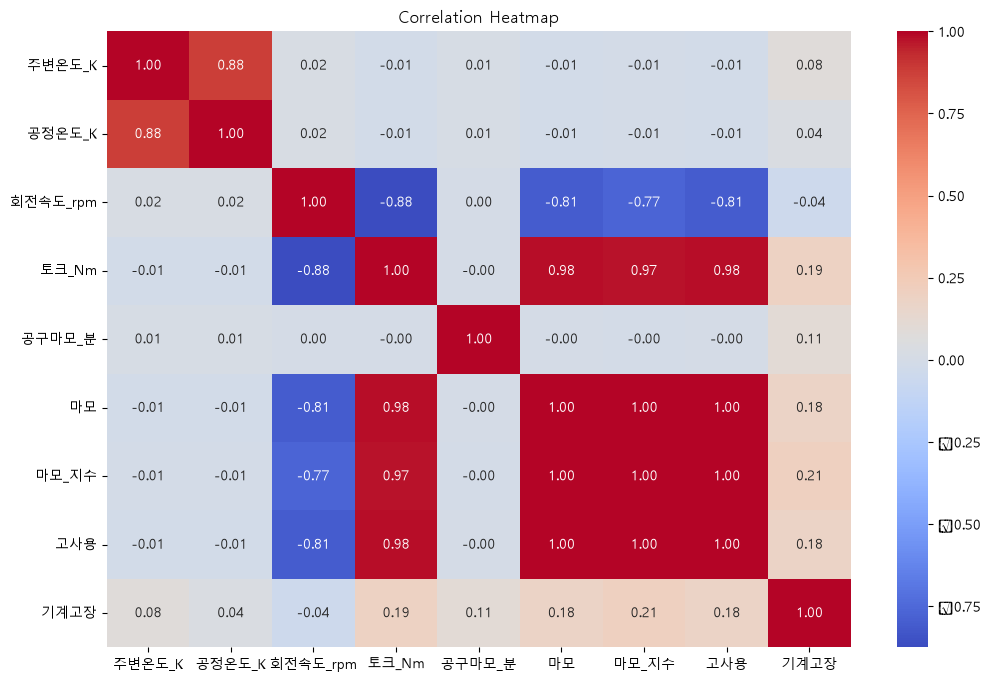

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 8))

df_fail = df_fail[[c for c in df_fail if c != '기계고장'] + ['기계고장']]

corr = df_fail.corr(numeric_only=True)

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")
plt.show()

# RPM별 고장 비율

RPM에 따라서 고장이 날 확률이 높다고 생각을 했습니다. 물론 RMP이 직접적인 원인이 아니겠지만, RPM이 올라감으로 인하여 생기는 여러가지 효과들로 그렇다고 생각을 해서 RPM별 고장 비율을 확인하기로 했습니다.

In [22]:
df_fail['회전속도_rpm'].describe()

count    10000.000000
mean      1538.776100
std        179.284096
min       1168.000000
25%       1423.000000
50%       1503.000000
75%       1612.000000
max       2886.000000
Name: 회전속도_rpm, dtype: float64

In [23]:
rpm_bins = [1100, 1300, 1400, 1500, 1600, 1700, 1900, 2200, 3000]

rpm_labels = [
    '1100~1300',
    '1300~1400',
    '1400~1500',
    '1500~1600',
    '1600~1700',
    '1700~1900',
    '1900~2200',
    '2200~3000'
]

df_fail['RPM_구간'] = pd.cut(
    df_fail['회전속도_rpm'],
    bins=rpm_bins,
    labels=rpm_labels,
    right=False
)

rpm_failure = df_fail.groupby('RPM_구간', observed=True).agg(
    전체수=('기계고장', 'count'),
    고장수=('기계고장', 'sum'),
    고장률=('기계고장', 'mean')
)

rpm_failure['고장률'] *= 100

rpm_failure

,전체수,고장수,고장률
RPM_구간,,,
1100~1300,211,49,23.222749
1300~1400,1636,187,11.430318
1400~1500,3052,42,1.376147
1500~1600,2378,12,0.504626
1600~1700,1376,9,0.654070
1700~1900,936,5,0.534188
1900~2200,315,4,1.269841
2200~3000,96,31,32.291667


RPM이 높으면 고장이 많이 날 것이라는 예측이 맞긴 했으나, RPM이 2200을 넘는 시점과 RPM이 1300보다 낮은 시점에서 더 고장이 잘 나는 것을 확인했습니다.

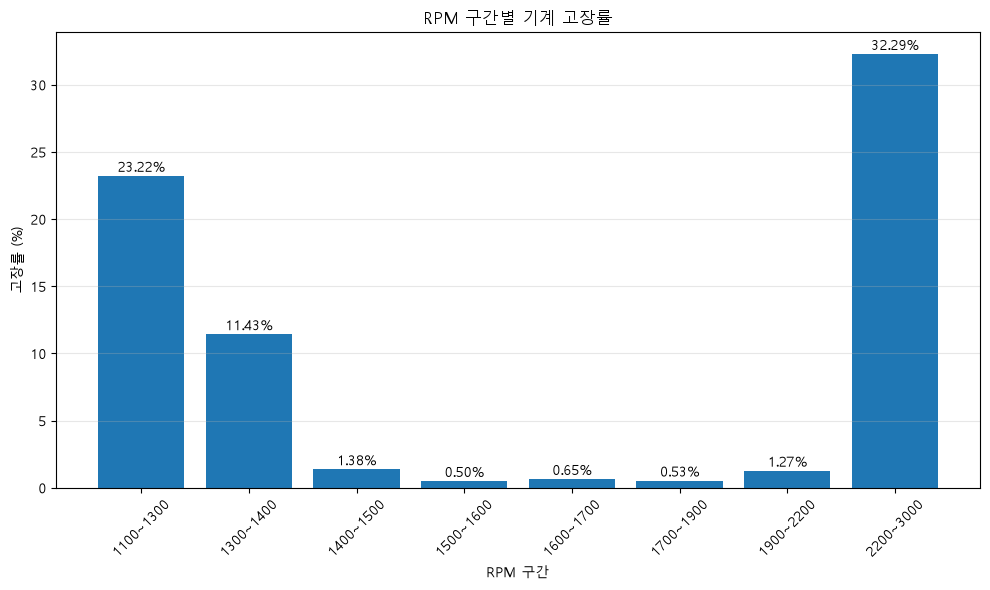

In [24]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.bar(
    rpm_failure.index.astype(str),
    rpm_failure['고장률']
)

plt.xlabel('RPM 구간')
plt.ylabel('고장률 (%)')
plt.title('RPM 구간별 기계 고장률')
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)

# 막대 위에 고장률 표시
for i, v in enumerate(rpm_failure['고장률']):
    plt.text(
        i, v + 0.3,
        f'{v:.2f}%',
        ha='center',
        fontsize=10
    )

plt.tight_layout()
plt.show()

이러면 RPM을 지수함수화 한다면, 뒷 부분은 잘 반영이 되겠지만, 앞 RPM이 낮은 부분은 반영이 되지 않아서 좋은 파생변수가 되지 않을 것이다. 그러면 어떻게 하면 좋을까? 위 그래프의 가장 윗 부분을 연결해보면 2차함수 그래프 처럼 나온다. 2차함수 그래프로 만들어보면 좋겠다.

In [25]:
df_fail['회전속도_파생2차'] = df_fail['회전속도_rpm']*df_fail['회전속도_rpm']

c:\Users\JUNSOO\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) Malgun Gothic.
  fig.canvas.draw()
C:\Users\JUNSOO\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) Malgun Gothic.
  fig.canvas.print_figure(bytes_io, **kw)


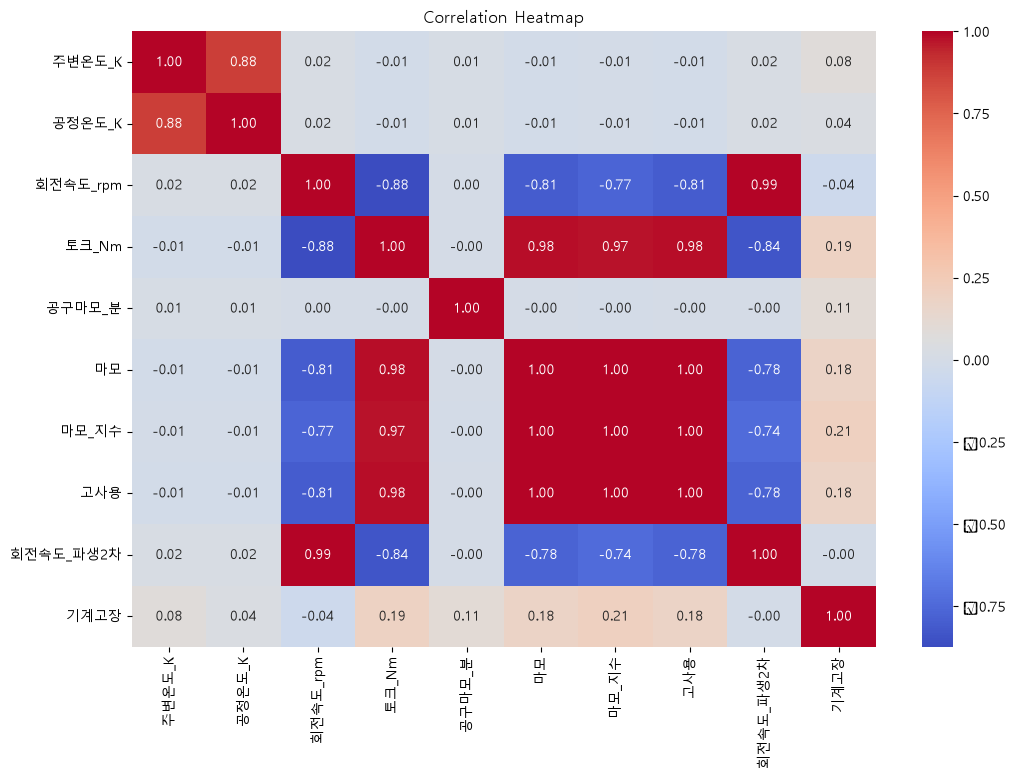

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 8))

df_fail = df_fail[[c for c in df_fail if c != '기계고장'] + ['기계고장']]

corr = df_fail.corr(numeric_only=True)

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")
plt.show()

에초에 RPM 자체가 큰 영역을 차지하지 않아서 이런 결과가 나온 것 같다. 1차로 만드는 파생 변수들을 상관계수가 높은 변수들로 만들기로 하자.

# 토크_Nm으로 파생변수를 만들어보자

In [27]:
df_fail['토크_Nm'].describe()

count    10000.000000
mean        39.986910
std          9.968934
min          3.800000
25%         33.200000
50%         40.100000
75%         46.800000
max         76.600000
Name: 토크_Nm, dtype: float64

In [28]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 토크 5 Nm 단위 구간
bins = np.arange(0, 81, 5)
labels = [f'{i}~{i+5}' for i in range(0, 80, 5)]

df_fail['토크_구간'] = pd.cut(
    df_fail['토크_Nm'],
    bins=bins,
    labels=labels,
    right=False
)

torque_failure = df_fail.groupby(
    '토크_구간',
    observed=True
).agg(
    전체수=('기계고장', 'count'),
    고장수=('기계고장', 'sum'),
    고장률=('기계고장', 'mean')
).reset_index()

torque_failure['고장률'] *= 100

torque_failure

,토크_구간,전체수,고장수,고장률
0,0~5,3,3,100.000000
1,5~10,8,8,100.000000
2,10~15,46,19,41.304348
3,15~20,171,4,2.339181
4,20~25,459,2,0.435730
5,25~30,889,7,0.787402
6,30~35,1466,6,0.409277
7,35~40,1898,13,0.684932
8,40~45,1934,13,0.672182
9,45~50,1553,53,3.412750


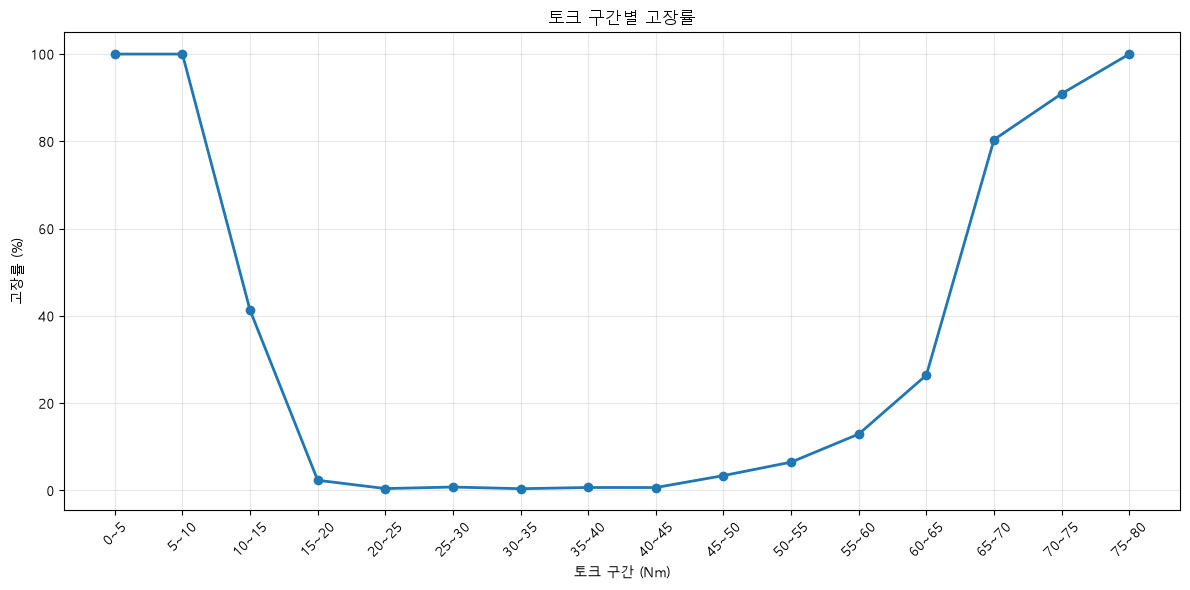

In [29]:
plt.figure(figsize=(12, 6))

plt.plot(
    torque_failure['토크_구간'],
    torque_failure['고장률'],
    marker='o',
    linewidth=2
)

plt.xlabel('토크 구간 (Nm)')
plt.ylabel('고장률 (%)')
plt.title('토크 구간별 고장률')

plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

토그 역시 RPM하고 같다. 2차함수로 적용해보자!

In [30]:
df_fail['토크_2차'] = df_fail['토크_Nm']*df_fail['토크_Nm']

c:\Users\JUNSOO\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) Malgun Gothic.
  fig.canvas.draw()
C:\Users\JUNSOO\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) Malgun Gothic.
  fig.canvas.print_figure(bytes_io, **kw)


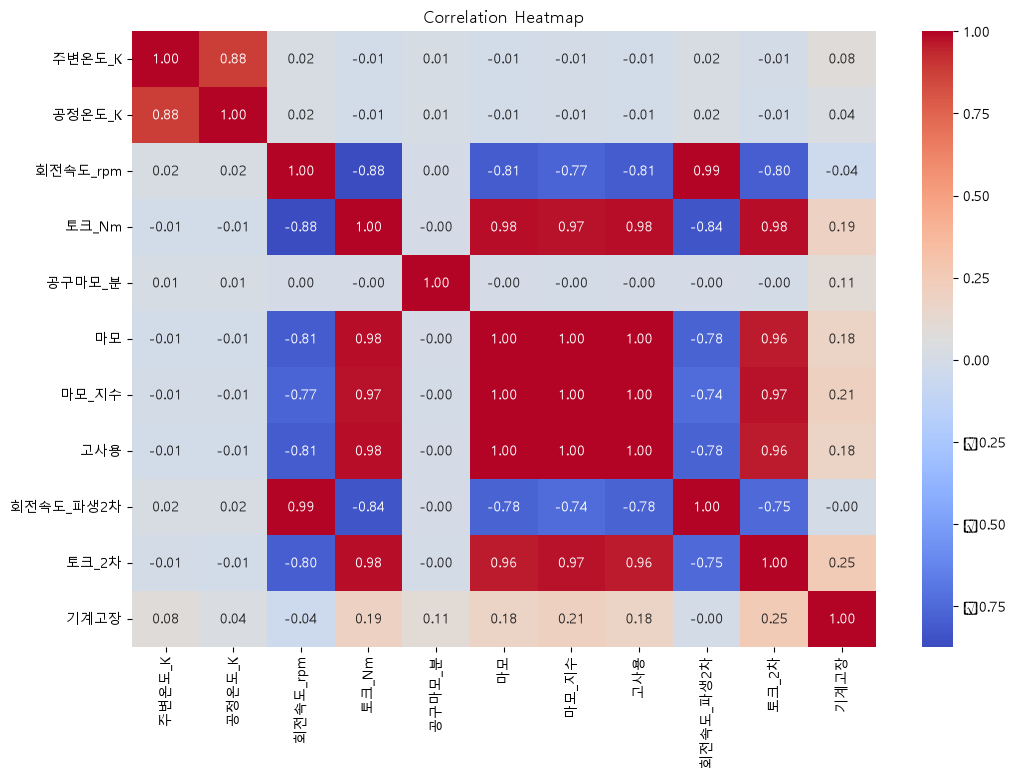

In [31]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 8))

df_fail = df_fail[[c for c in df_fail if c != '기계고장'] + ['기계고장']]

corr = df_fail.corr(numeric_only=True)

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")
plt.show()

# 공구마모 분 파생변수

In [32]:
df_fail['공구마모_분'].describe()

count    10000.000000
mean       107.951000
std         63.654147
min          0.000000
25%         53.000000
50%        108.000000
75%        162.000000
max        253.000000
Name: 공구마모_분, dtype: float64

In [33]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 공구마모 10분 단위 구간
bins = np.arange(0, 261, 10)
labels = [f'{i}~{i+10}' for i in range(0, 260, 10)]

df_fail['공구마모_구간'] = pd.cut(
    df_fail['공구마모_분'],
    bins=bins,
    labels=labels,
    right=False
)

wear_failure = df_fail.groupby(
    '공구마모_구간',
    observed=True
).agg(
    전체수=('기계고장', 'count'),
    고장수=('기계고장', 'sum'),
    고장률=('기계고장', 'mean')
).reset_index()

wear_failure['고장률'] *= 100

wear_failure

,공구마모_구간,전체수,고장수,고장률
0,0~10,500,12,2.400000
1,10~20,473,10,2.114165
2,20~30,461,12,2.603037
3,30~40,458,8,1.746725
4,40~50,457,10,2.188184
5,50~60,461,6,1.301518
6,60~70,452,16,3.539823
7,70~80,458,8,1.746725
8,80~90,447,10,2.237136
9,90~100,453,11,2.428256


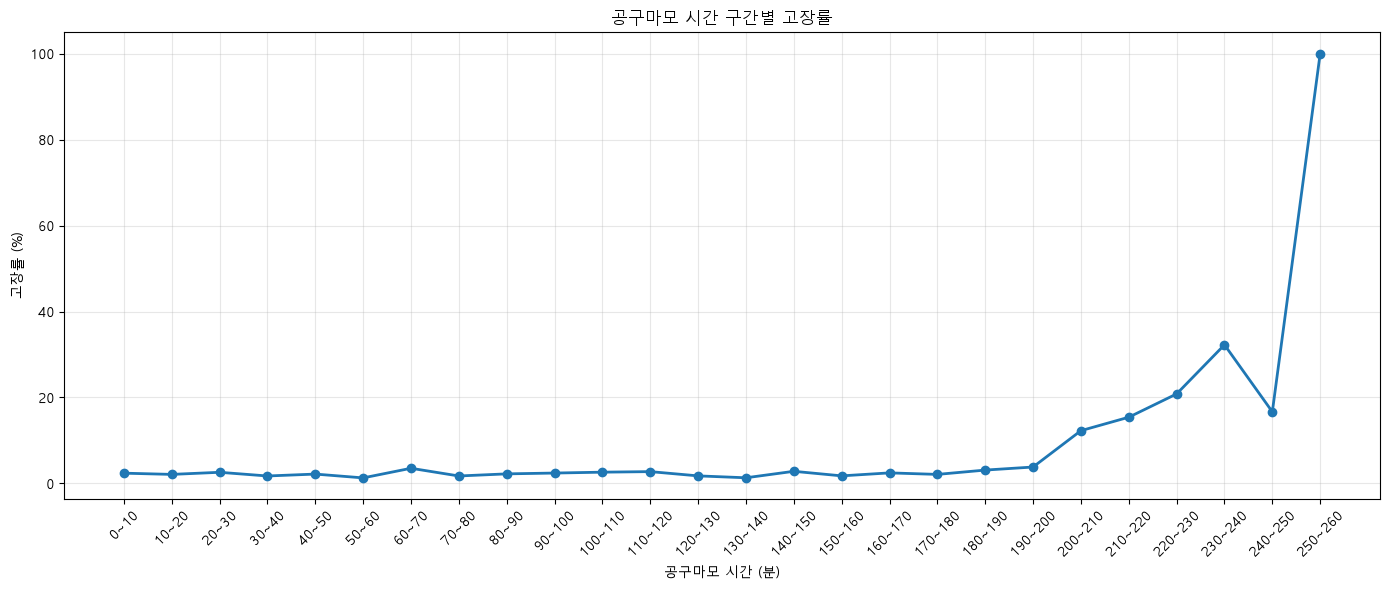

In [34]:
plt.figure(figsize=(14, 6))

plt.plot(
    wear_failure['공구마모_구간'],
    wear_failure['고장률'],
    marker='o',
    linewidth=2
)

plt.xlabel('공구마모 시간 (분)')
plt.ylabel('고장률 (%)')
plt.title('공구마모 시간 구간별 고장률')

plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [35]:
import numpy as np
from sklearn.preprocessing import MinMaxScaler

# 1. 공구마모 시간 스케일링
scaler = MinMaxScaler()

df_fail['공구마모_스케일'] = scaler.fit_transform(
    df_fail[['공구마모_분']]
)

# 2. 지수함수화
df_fail['공구마모_지수'] = np.exp(
    df_fail['공구마모_스케일']
)

df_fail = df_fail.drop(columns=['공구마모_스케일'])

c:\Users\JUNSOO\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) Malgun Gothic.
  fig.canvas.draw()
C:\Users\JUNSOO\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) Malgun Gothic.
  fig.canvas.print_figure(bytes_io, **kw)


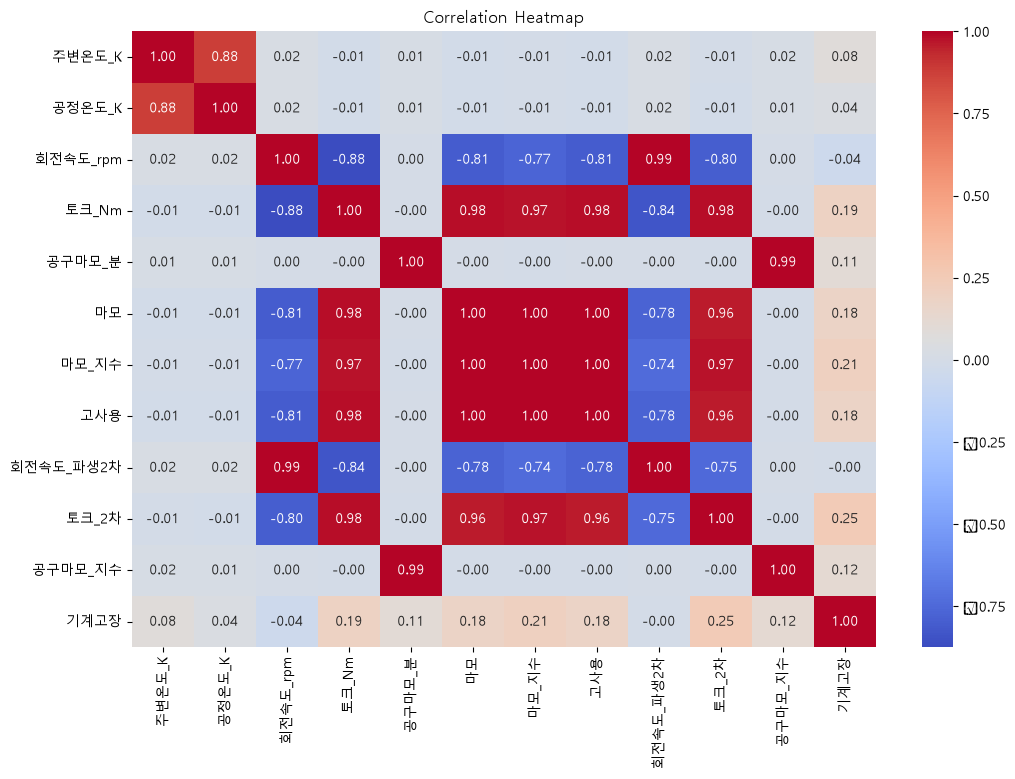

In [36]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 8))

df_fail = df_fail[[c for c in df_fail if c != '기계고장'] + ['기계고장']]

corr = df_fail.corr(numeric_only=True)

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")
plt.show()

생각을 해봤는데, 공정 온도가 높은데 주변 온도도 높으면 고장이 잘 나지 않을까요? 한번 시도해보죠

In [37]:
df_fail['온도차'] = df_fail['공정온도_K'] - df_fail['주변온도_K']

c:\Users\JUNSOO\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) Malgun Gothic.
  fig.canvas.draw()
C:\Users\JUNSOO\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) Malgun Gothic.
  fig.canvas.print_figure(bytes_io, **kw)


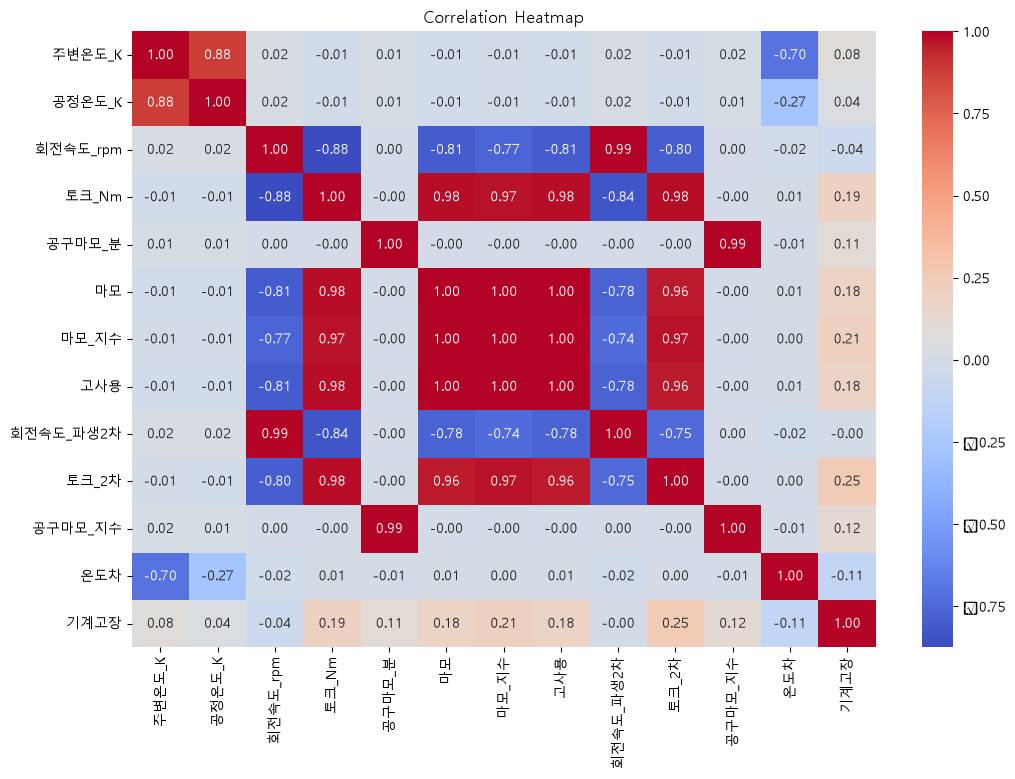

In [38]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 8))

df_fail = df_fail[[c for c in df_fail if c != '기계고장'] + ['기계고장']]

corr = df_fail.corr(numeric_only=True)

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")
plt.show()

그러면 이 온도차 파생변수를 또 파생변수로 만들어보겠습니다.

In [39]:
df_fail['온도차'].describe()

count    10000.000000
mean        10.000630
std          1.001094
min          7.600000
25%          9.300000
50%          9.800000
75%         11.000000
max         12.100000
Name: 온도차, dtype: float64

In [40]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 온도차 0.5K 단위 구간
bins = np.arange(7.5, 12.6, 0.5)
labels = [f'{i:.1f}~{i+0.5:.1f}' for i in np.arange(7.5, 12.5, 0.5)]

df_fail['온도차_구간'] = pd.cut(
    df_fail['온도차'],
    bins=bins,
    labels=labels,
    right=False
)

temp_failure = df_fail.groupby(
    '온도차_구간',
    observed=True
).agg(
    전체수=('기계고장', 'count'),
    고장수=('기계고장', 'sum'),
    고장률=('기계고장', 'mean')
).reset_index()

temp_failure['고장률'] *= 100

temp_failure

,온도차_구간,전체수,고장수,고장률
0,7.5~8.0,194,30,15.463918
1,8.0~8.5,368,64,17.391304
2,8.5~9.0,873,53,6.071019
3,9.0~9.5,1995,43,2.155388
4,9.5~10.0,1905,42,2.204724
5,10.0~10.5,778,20,2.570694
6,10.5~11.0,1324,33,2.492447
7,11.0~11.5,2119,50,2.359604
8,11.5~12.0,411,3,0.729927
9,12.0~12.5,33,1,3.030303


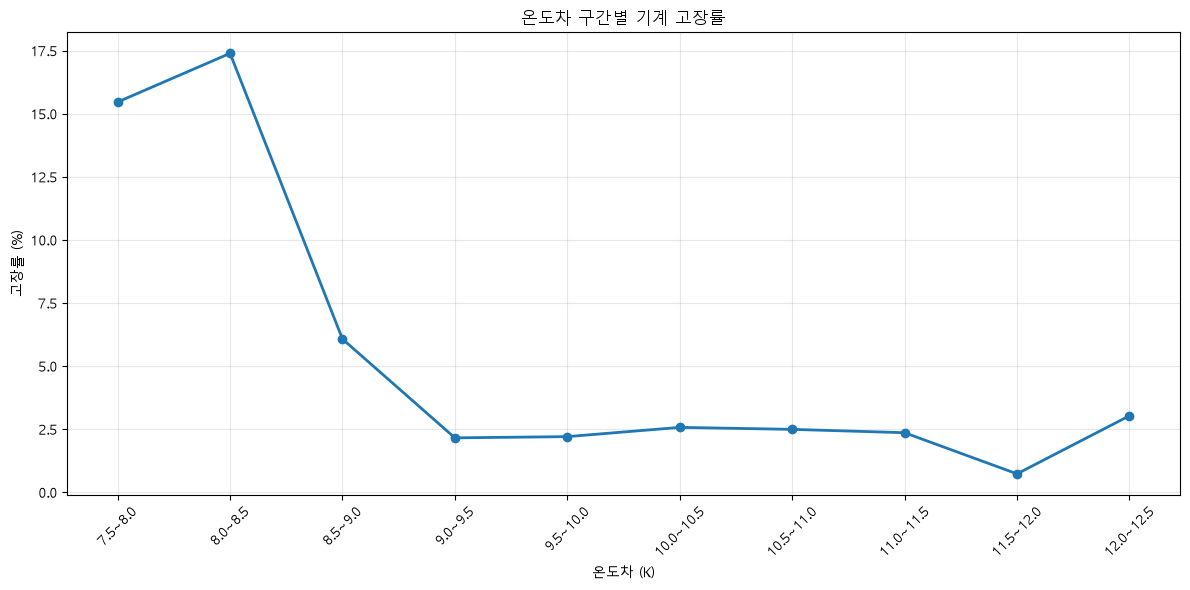

In [41]:
plt.figure(figsize=(12, 6))

plt.plot(
    temp_failure['온도차_구간'],
    temp_failure['고장률'],
    marker='o',
    linewidth=2
)

plt.xlabel('온도차 (K)')
plt.ylabel('고장률 (%)')
plt.title('온도차 구간별 기계 고장률')

plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

이 형태는 로그 함수인 것 같네요!

In [42]:
df_fail['온도차_로그'] = np.log(df_fail['온도차'])

c:\Users\JUNSOO\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) Malgun Gothic.
  fig.canvas.draw()
C:\Users\JUNSOO\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) Malgun Gothic.
  fig.canvas.print_figure(bytes_io, **kw)


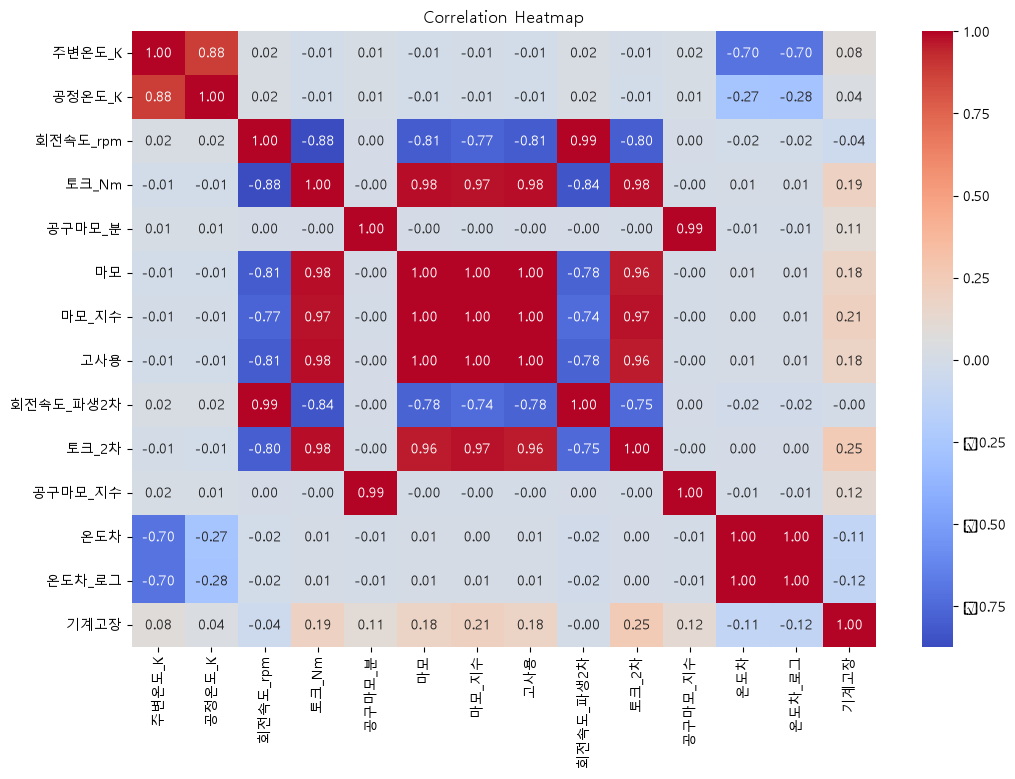

In [43]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 8))

df_fail = df_fail[[c for c in df_fail if c != '기계고장'] + ['기계고장']]

corr = df_fail.corr(numeric_only=True)

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")
plt.show()

확실히 변수 하나로 파생변수를 만드는 거는 한계가 있어 보입니다. 그러면 도메인 지식을 바탕으로 하는 변수끼리 합성하는 파생변수를 만들어봐야겠네요.

# 결합변수

일단 베이스를 잡고 가봅시다. <br></br> 토크란?  절삭 가공 중 주축과 공구가 공작물을 깎아낼 때 발생하는 회전력입니다. <br></br> 그러면 토크가 높은데, 회전력이 낮으면 문제가 생기겠죠? 그 반대도 문제가 생길 수 있을 거라고 생각을 했습니다. 그러면 이거를 어떻게 적용해보는게 좋을까요? 일단 확인을 해볼까요?

In [44]:
df_fail['마모_토크'] = df_fail['마모_지수'] * df_fail['토크_2차']
df_fail['기계적_스트레스'] = df_fail['온도차'] * df_fail['토크_2차']
df_fail['power_low'] = df_fail['회전속도_파생2차'] * df_fail['토크_2차']
df_fail['누적_피로'] = df_fail['고사용'] * df_fail['마모_지수']
df_fail['마모_지수_2차'] = df_fail['마모_지수']**2
df_fail['마모_지수_3차'] = df_fail['마모_지수']**3
df_fail['안전_마진_지수'] = df_fail['토크_Nm'] / (df_fail['회전속도_rpm']+1)
df_fail['노후도'] = (df_fail['마모_지수'] + df_fail['토크_2차'] + df_fail['고사용'])/3
df_fail['고장위험도'] = df_fail['마모_토크'] * df_fail['공구마모_분']
df_fail['복합_스트레스'] = df_fail['마모_토크'] * df_fail['온도차']

high_risk_cols = ['마모_토크', '마모_지수_3차', '고장위험도']

for col in high_risk_cols:
    q95 = df_fail[col].quantile(0.95)
    df_fail[f'{col}_극단위험_95'] = (df_fail[col] > q95).astype(int)


In [45]:
from scipy.stats import zscore

q97_risk = df_fail['고장위험도'].quantile(0.97)
q97_wear_torque = df_fail['마모_토크'].quantile(0.97)

df_fail['고장위험도_극단위험_97'] = (df_fail['고장위험도'] > q97_risk).astype(int)
df_fail['마모_토크_극단위험_97'] = (df_fail['마모_토크'] > q97_wear_torque).astype(int)


# =========================================================
# 2. 종합 위험 스코어 (위험 플래그 합산)
# =========================================================
risk_flags = [
    '마모_토크_극단위험_95',
    '마모_지수_3차_극단위험_95',
    '고장위험도_극단위험_95',
]
df_fail['종합_위험_스코어'] = df_fail[risk_flags].sum(axis=1)


# =========================================================
# 3. 다중 조건 동시 충족 플래그 (AND 조건)
# =========================================================
# 마모_토크 상위 10% 이면서 동시에 공구마모_분 상위 10% 인 경우
q90_wear_torque = df_fail['마모_토크'].quantile(0.90)
q90_tool_wear = df_fail['공구마모_분'].quantile(0.90)

df_fail['다중_극단위험_AND'] = (
    (df_fail['마모_토크'] > q90_wear_torque)
    & (df_fail['공구마모_분'] > q90_tool_wear)
).astype(int)


# =========================================================
# 4. 종합 Z-Score (표준화 누적 부하)
# =========================================================
df_fail['종합_Z_Score'] = (
    zscore(df_fail['마모_토크'])
    + zscore(df_fail['공구마모_분'])
    + zscore(df_fail['토크_2차'])
)


# =========================================================
# 5. 고장위험도 2차 비선형 변수
# =========================================================
df_fail['고장위험도_2차'] = df_fail['고장위험도'] ** 2
df_fail['고장위험도_3차'] = df_fail['고장위험도'] ** 3

c:\Users\JUNSOO\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) Malgun Gothic.
  fig.canvas.draw()
C:\Users\JUNSOO\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) Malgun Gothic.
  fig.canvas.print_figure(bytes_io, **kw)


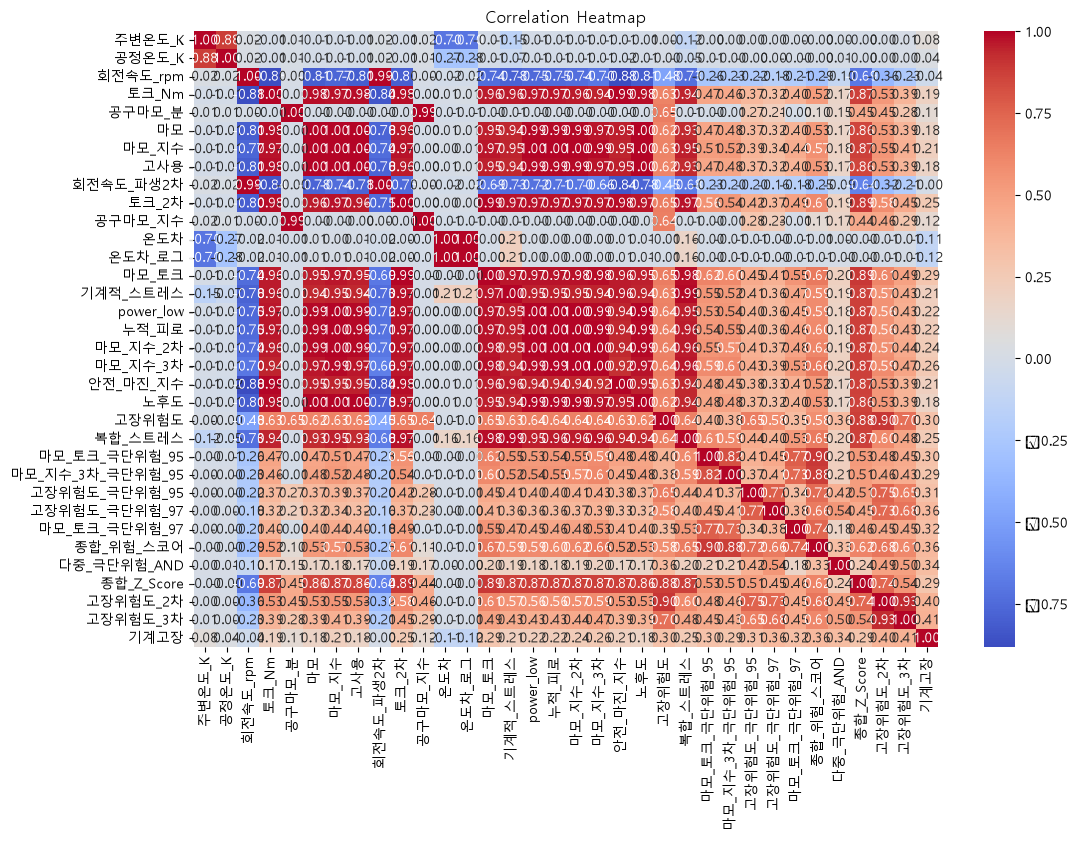

In [46]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 8))

df_fail = df_fail[[c for c in df_fail if c != '기계고장'] + ['기계고장']]

corr = df_fail.corr(numeric_only=True)

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")
plt.show()

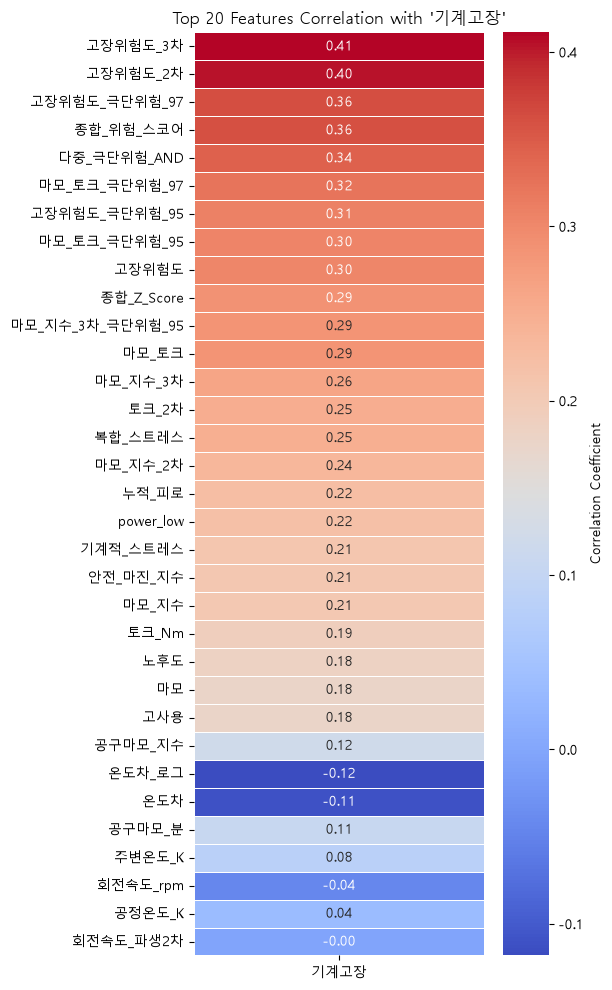

In [47]:
import matplotlib.pyplot as plt
import seaborn as sns

# 한글 폰트 설정 (Windows: Malgun Gothic, Mac: AppleGothic)
plt.rc('font', family='Malgun Gothic') 
plt.rc('axes', unicode_minus=False)    # 마이너스 기호 깨짐 방지

# 1. 상관계수 계산
corr = df_fail.corr(numeric_only=True)

# 2. '기계고장'과의 상관계수 절댓값이 가장 높은 상위 20개 변수 추출 ('기계고장' 자기 자신은 제외)
top20_cols = corr['기계고장'].drop('기계고장').abs().sort_values(ascending=False).head(40).index

# 3. 상위 20개 변수와 '기계고장' 간의 상관계수만 2차원(20x1) 데이터프레임으로 추출
top20_corr_target = corr.loc[top20_cols, ['기계고장']]

# 4. 히트맵 시각화 (기계고장과의 상관계수 전용)
plt.figure(figsize=(6, 10))
sns.heatmap(
    top20_corr_target,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5,
    cbar_kws={'label': 'Correlation Coefficient'}
)

plt.title("Top 20 Features Correlation with '기계고장'")
plt.tight_layout()
plt.show()

In [52]:
df_fail.columns

Index(['제품ID', '제품등급', '주변온도_K', '공정온도_K', '회전속도_rpm', '토크_Nm', '공구마모_분', '마모',
       '마모_지수', '고사용', 'RPM_구간', '회전속도_파생2차', '토크_구간', '토크_2차', '공구마모_구간',
       '공구마모_지수', '온도차', '온도차_구간', '온도차_로그', '마모_토크', '기계적_스트레스', 'power_low',
       '누적_피로', '마모_지수_2차', '마모_지수_3차', '안전_마진_지수', '노후도', '고장위험도', '복합_스트레스',
       '마모_토크_극단위험_95', '마모_지수_3차_극단위험_95', '고장위험도_극단위험_95', '고장위험도_극단위험_97',
       '마모_토크_극단위험_97', '종합_위험_스코어', '다중_극단위험_AND', '종합_Z_Score', '고장위험도_2차',
       '고장위험도_3차', '기계고장'],
      dtype='str')

In [ ]:
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from collections import Counter

X = df_fail.drop(columns=['기계고장','제품ID'])
y = df_fail['기계고장']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("SMOTE 적용 전: ", Counter(y_train))

smote = SMOTE(
    sampling_strategy='auto',
    random_state=42,
    k_neighbors=5
)

X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

SMOTE 적용 전:  Counter({0: 7729, 1: 271})


C:\Users\JUNSOO\AppData\Local\Temp\ipykernel_8512\3400224349.py:15: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  X_train.select_dtypes(include='object').columns


ValueError: could not convert string to float: 'M'